注意: third_order_gramはseed不明・競合上書きの暫定結果。再実行後に差し替えること。
読み込めたレコード: ['plain_step47921', 'plain_step62059', 'del_conrad', 'del_gaussian', 'del_ics', 'del_truncated_normal', 'del_third_order_gram_UNVERIFIED']
plain_step47921      step= 47921 accept_mb=0.515  accept_fb=N/A  dist_final=N/A
plain_step62059      step= 62059 accept_mb=0.515  accept_fb=N/A  dist_final=N/A
del_conrad           step= 62000 accept_mb=0.525  accept_fb=0.5892132644684367  dist_final=73.61174011230469
del_gaussian         step= 62000 accept_mb=0.514  accept_fb=0.5223066506849646  dist_final=73.6030502319336
del_ics              step= 62000 accept_mb=0.642  accept_fb=0.7648082244451809  dist_final=73.61265563964844
del_truncated_normal step= 62000 accept_mb=0.508  accept_fb=0.5186796643164676  dist_final=73.60307312011719
del_third_order_gram_UNVERIFIED step= 62000 accept_mb=0.516  accept_fb=0.5198445491230803  dist_final=73.60660552978516


/tmp/ipykernel_149624/2128175401.py:70: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:70: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:70: UserWarning: Glyph 26283 (\N{CJK UNIFIED IDEOGRAPH-66AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:70: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


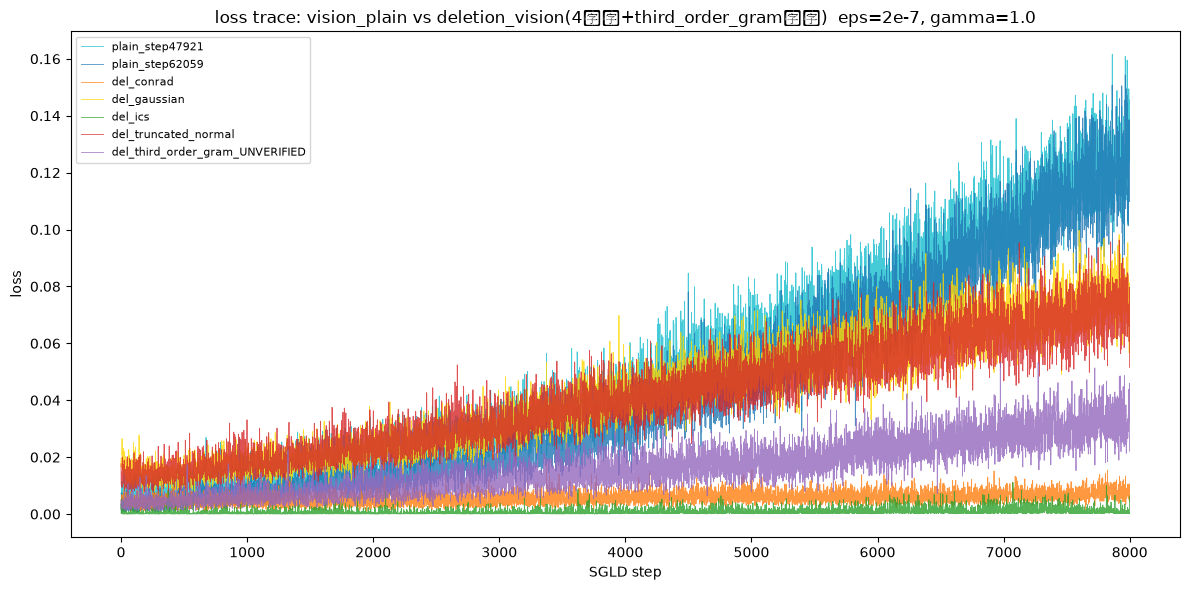

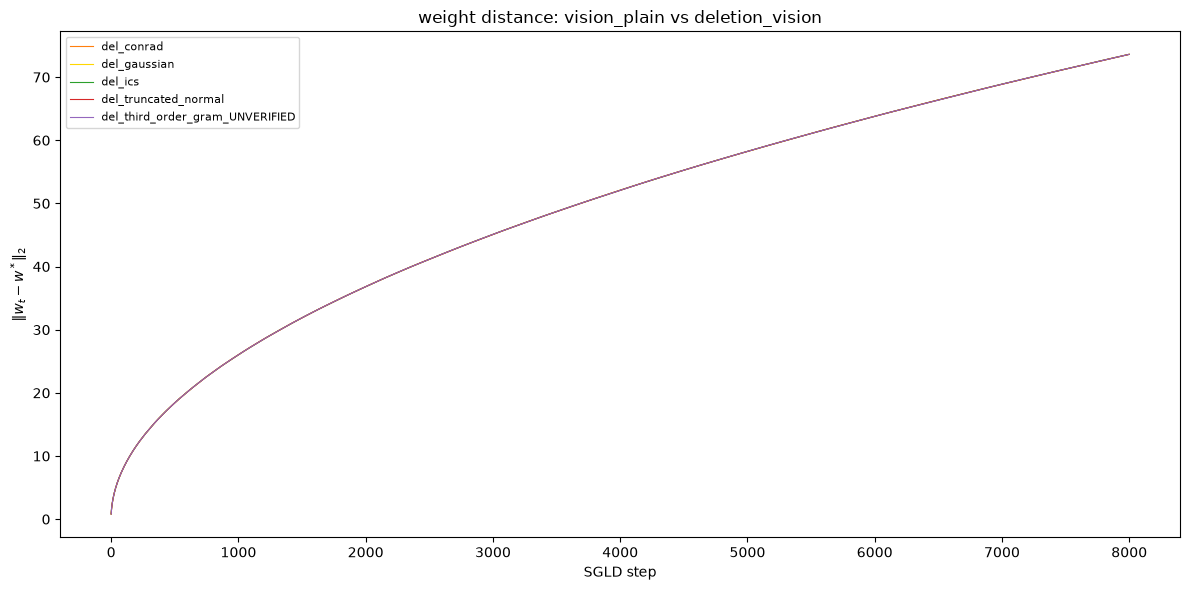

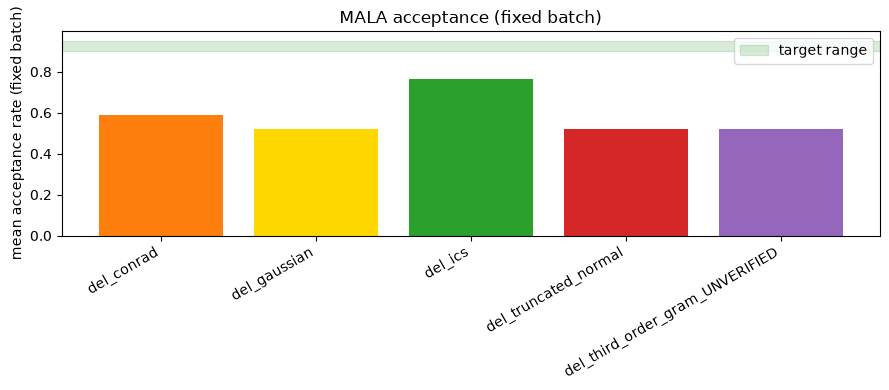

plain_step47921        ['209.10', '267.88', '312.61', '329.53']
plain_step62059        ['189.71', '245.44', '290.34', '307.74']
del_conrad             ['8.85', '10.67', '11.90', '12.22']
del_gaussian           ['109.07', '146.71', '173.29', '181.91']
del_ics                ['-7.54', '-7.08', '-6.56', '-6.38']
del_truncated_normal   ['129.97', '164.49', '186.92', '193.92']
del_third_order_gram_UNVERIFIED ['55.62', '71.00', '81.11', '84.56']


/tmp/ipykernel_149624/2128175401.py:139: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:139: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:139: UserWarning: Glyph 26283 (\N{CJK UNIFIED IDEOGRAPH-66AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_149624/2128175401.py:139: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


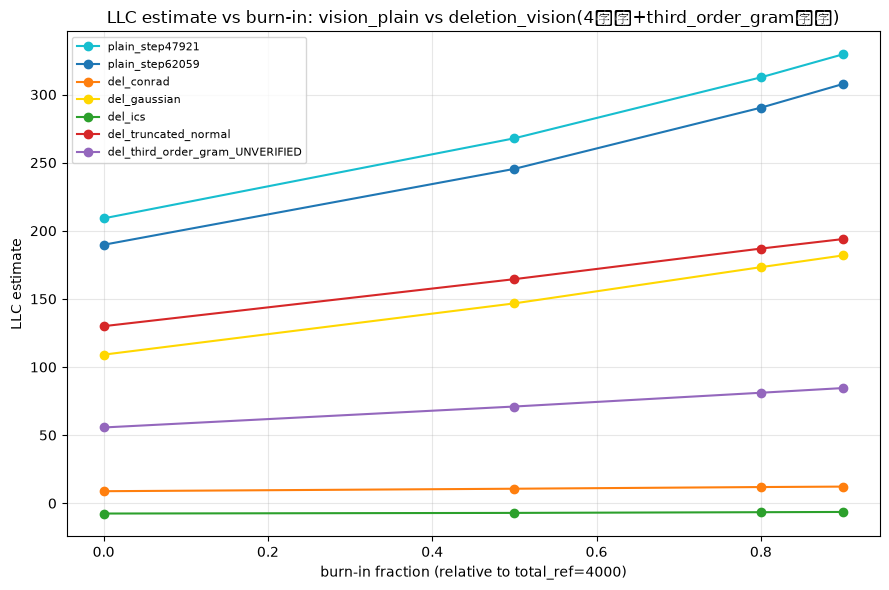

In [4]:
# ── 統合セル: vision_plain + deletion(4手法) + third_order_gram(暫定) の読み込み・描画 ──
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- vision_plain (通常学習) ---
VISION_PLAIN_ROOT = Path("/home/nakano/server/calibration_results_vision_resnet_setting")
vision_plain_records = {}
for f in VISION_PLAIN_ROOT.glob("calib_convnext-atto_step*.json"):
    d = json.load(open(f))
    for r in d["records"]:
        if abs(r["epsilon"] - 2e-7) < 1e-9 and r["gamma"] == 1.0 and r["total_steps"] == 8000:
            vision_plain_records[f"plain_step{r['step']}"] = r

# --- deletion_vision (既存4手法) ---
DELETION_ROOT = Path("/home/nakano/server/calibration_results_deletion_vision_resnet_setting")
METHODS = ["conrad", "gaussian", "ics", "truncated_normal"]
deletion_records = {}
for method in METHODS:
    f = DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_step62000.json"
    if not f.exists():
        print(f"{method}: NOT FOUND ({f})")
        continue
    d = json.load(open(f))
    recs = [r for r in d["records"] if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000]
    if recs:
        deletion_records[f"del_{method}"] = recs[0]
    else:
        print(f"{method}: file exists but no matching record")

# --- third_order_gram (暫定: seed不明・競合上書き結果、要再実行) ---
f = DELETION_ROOT / "calib_convnext-atto_deletion_third_order_gram_step62000.json"
if f.exists():
    d = json.load(open(f))
    recs = [r for r in d["records"] if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000]
    if recs:
        deletion_records["del_third_order_gram_UNVERIFIED"] = recs[0]
        print("注意: third_order_gramはseed不明・競合上書きの暫定結果。再実行後に差し替えること。")
else:
    print("third_order_gram: NOT FOUND")

# 統合
all_records = {**vision_plain_records, **deletion_records}
print("読み込めたレコード:", list(all_records.keys()))
for name, r in all_records.items():
    print(f"{name:20s} step={r['step']:6d} accept_mb={r['mean_accept_prob_full']:.3f}  "
          f"accept_fb={r.get('fixed_batch_mala_accept_mean', 'N/A')}  "
          f"dist_final={r.get('weight_distance_final', 'N/A')}")

# ── 色分け ──
colors = {
    "plain_step47921": "tab:cyan",
    "plain_step62059": "tab:blue",
    "del_conrad": "tab:orange",
    "del_gaussian": "gold",
    "del_ics": "tab:green",
    "del_truncated_normal": "tab:red",
    "del_third_order_gram_UNVERIFIED": "tab:purple",
}

# ── loss trace 比較 ──
fig, ax = plt.subplots(figsize=(12, 6))
for name, r in all_records.items():
    ax.plot(r["loss_trace"], linewidth=0.6, label=name, color=colors.get(name), alpha=0.8)
ax.set_xlabel("SGLD step")
ax.set_ylabel("loss")
ax.set_title("loss trace: vision_plain vs deletion_vision(4手法+third_order_gram暫定)  eps=2e-7, gamma=1.0")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── weight distance 比較 ──
fig, ax = plt.subplots(figsize=(12, 6))
for name, r in all_records.items():
    if "weight_distance_trace" not in r:
        continue
    ax.plot(r["weight_distance_trace"], linewidth=0.8, label=name, color=colors.get(name))
ax.set_xlabel("SGLD step")
ax.set_ylabel(r"$\|w_t - w^*\|_2$")
ax.set_title("weight distance: vision_plain vs deletion_vision")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 固定バッチ受理率(棒グラフ) ──
names_with_fb = [n for n, r in all_records.items() if "fixed_batch_mala_accept_mean" in r]
fb_values = [all_records[n]["fixed_batch_mala_accept_mean"] for n in names_with_fb]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(names_with_fb, fb_values, color=[colors.get(n) for n in names_with_fb])
ax.axhspan(0.9, 0.95, color="green", alpha=0.15, label="target range")
ax.set_ylabel("mean acceptance rate (fixed batch)")
ax.set_title("MALA acceptance (fixed batch)")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ── burn-in を揃えたLLC比較 ──
def compute_llc_from_trace(loss_trace, l_w_star, nbeta,
                             burn_in_frac=0.0, burn_in_steps=None, total_ref=None):
    loss_trace = np.array(loss_trace)
    if burn_in_steps is not None:
        n_burn = burn_in_steps
    else:
        base = total_ref if total_ref is not None else len(loss_trace)
        n_burn = int(base * burn_in_frac)
    n_burn = min(n_burn, len(loss_trace) - 1)
    tail = loss_trace[n_burn:]
    return nbeta * (np.mean(tail) - l_w_star)

burn_in_fracs = [0.0, 0.5, 0.8, 0.9]
total_ref = 4000

llc_by_burnin = {name: [] for name in all_records}

for name, r in all_records.items():
    l_w_star_approx = np.mean(r["loss_trace"][:5])
    nbeta = r["nbeta"]
    for frac in burn_in_fracs:
        llc = compute_llc_from_trace(
            r["loss_trace"], l_w_star_approx, nbeta,
            burn_in_frac=frac, total_ref=total_ref)
        llc_by_burnin[name].append(llc)

for name in all_records:
    print(f"{name:22s}", [f"{v:.2f}" for v in llc_by_burnin[name]])

# ── burn-in vs LLC 折れ線 ──
fig, ax = plt.subplots(figsize=(9, 6))
for name in all_records:
    ax.plot(burn_in_fracs, llc_by_burnin[name], marker="o", label=name, color=colors.get(name))
ax.set_xlabel(f"burn-in fraction (relative to total_ref={total_ref})")
ax.set_ylabel("LLC estimate")
ax.set_title(f"LLC estimate vs burn-in: vision_plain vs deletion_vision(4手法+third_order_gram暫定)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()